# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings

In [2]:
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# Load Dataset

In [3]:
df = pd.read_csv("/content/winequality-red.csv")

# # Number of rows & columns in the dataset

In [4]:
df.shape

(1599, 12)

# First 5 rows of the dataset

In [5]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


- There are no null value in the dataset.

# Summary Statistics

In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


- Several features contain outliers.
- Some columns are skewed (residual sugar, chlorides, sulfur dioxide).
- Feature scaling is recommended before machine learning.
- Alcohol and acidity-related features are likely important predictors of wine quality.

# Check Missing Values

In [8]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


There are no missing value in the dataset.

# Check Duplicate Rows

In [10]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,True
...,...
1594,False
1595,False
1596,True
1597,False


In [9]:
df.duplicated().sum()

np.int64(240)

240 duplicate value in the dataset.

# Remove duplicates

In [11]:
df = df.drop_duplicates()

In [13]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5


In [14]:
df.duplicated().sum()

np.int64(0)

There no duplicate value in the dataset.

# Number of values for each quality

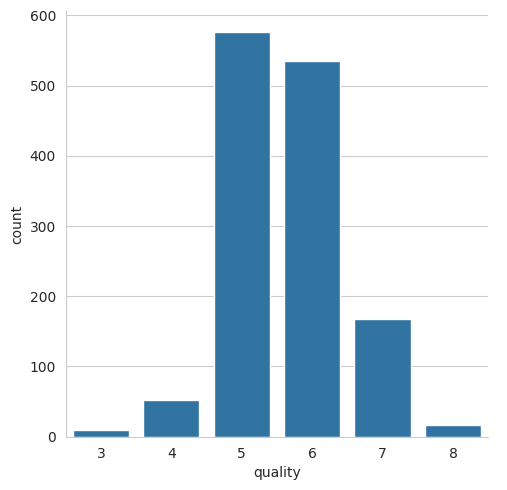

In [19]:
sns.catplot(x='quality', data = df, kind = 'count')

## volatile acidity vs quality

<Axes: xlabel='quality', ylabel='volatile acidity'>

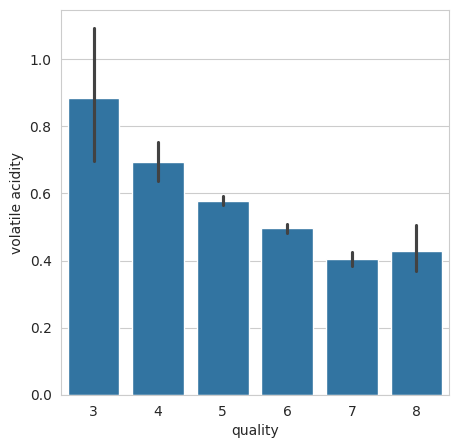

In [20]:
plot = plt.figure(figsize=(5,5))
sns.barplot(x='quality', y = 'volatile acidity', data = df)

# Correlation Matrix


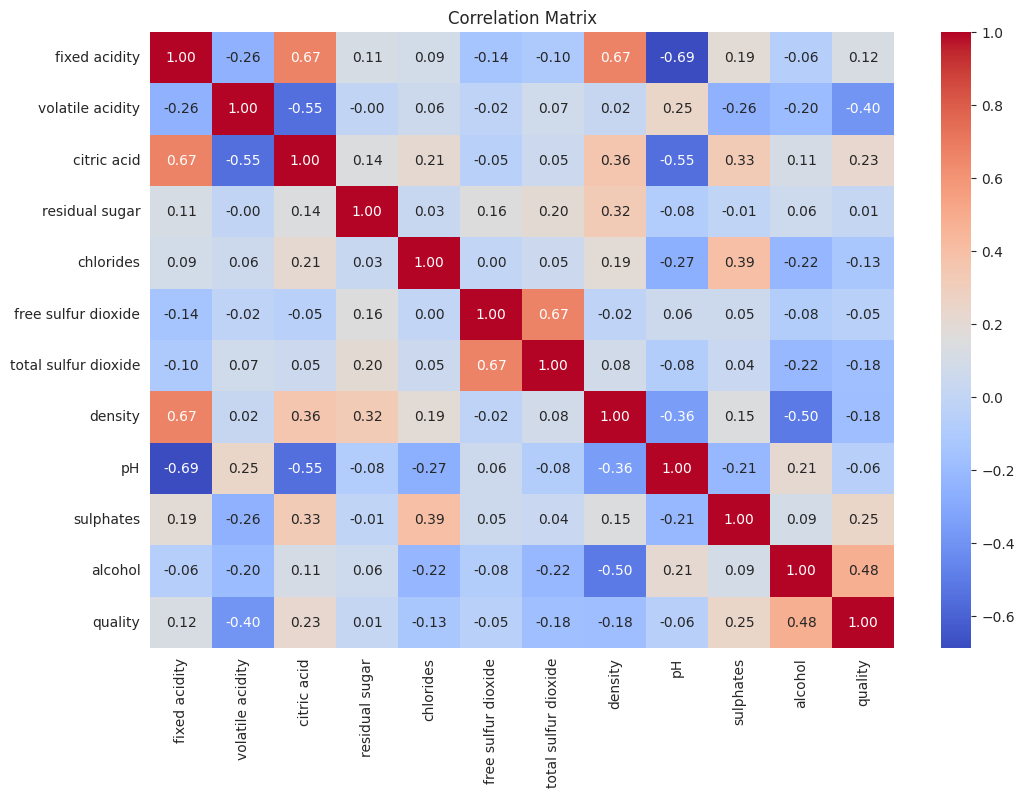

In [15]:
plt.figure(figsize=(12,8))
corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()


# Constructing a heatmap to understand the correlation between the columns

<Axes: >

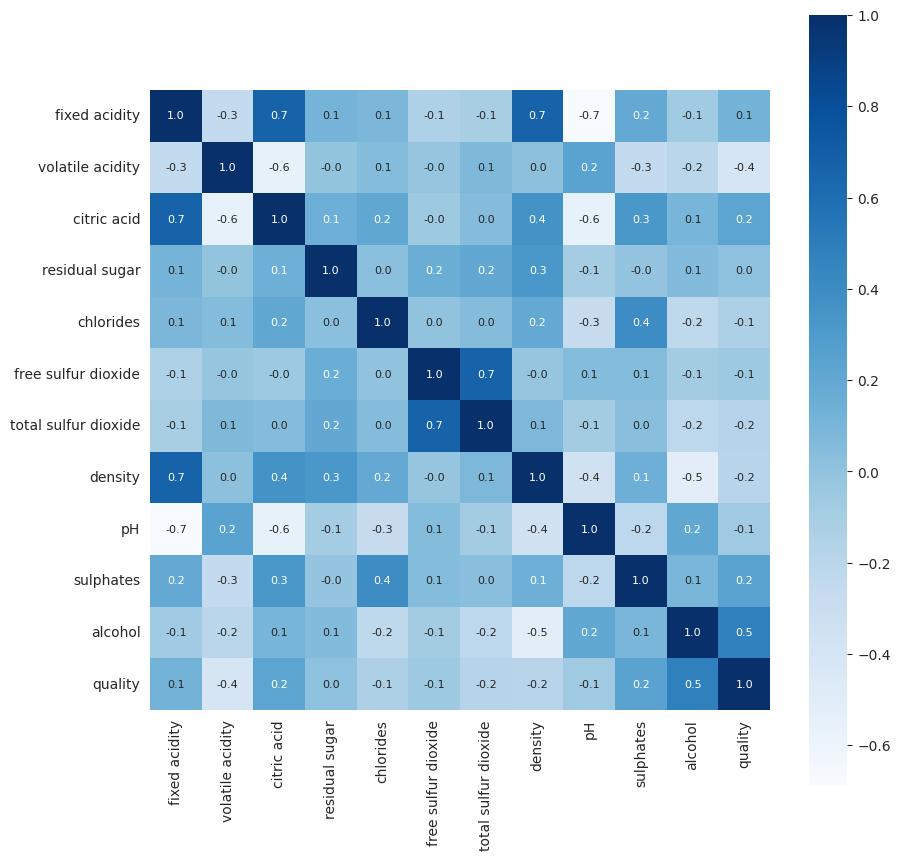

In [17]:
plt.figure(figsize=(10,10))
sns.heatmap(corr, cbar=True, square=True, fmt = '.1f', annot = True, annot_kws={'size':8}, cmap = 'Blues')

# Correlation

- Positive Correlation
- Negative Correlation

# Distribution of Features

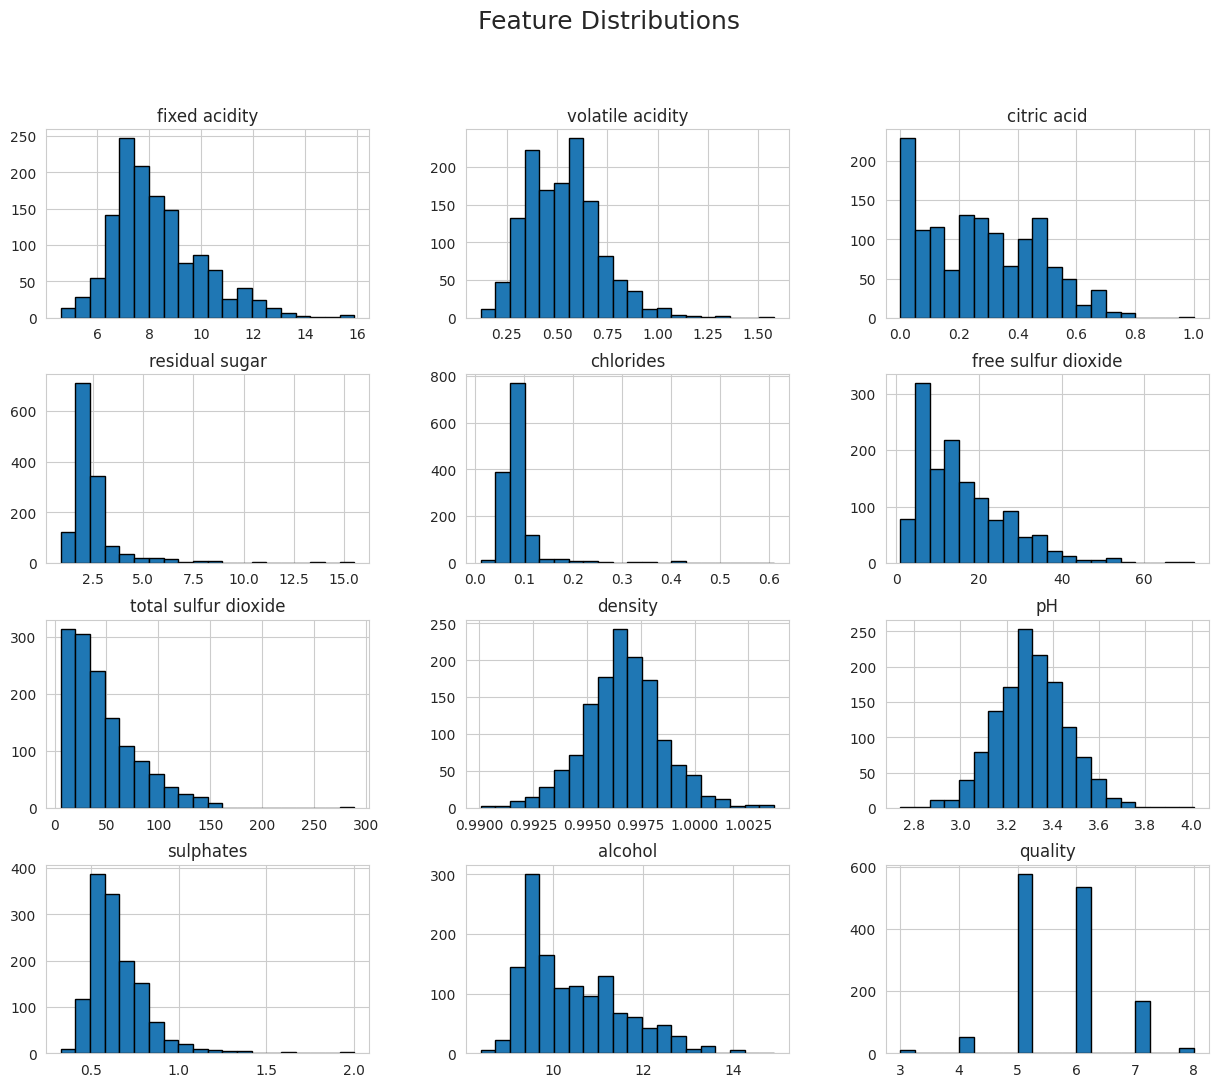

In [18]:
df.hist(
    figsize=(15,12),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Feature Distributions", fontsize=18)
plt.show()


# From the Histograms:
- Many features are skewed and contain outliers.
- Feature scaling and transformation are recommended.
- The target variable (quality) is imbalanced.
- Data preprocessing will significantly improve machine learning model performance.

# Boxplots for Outlier Detection

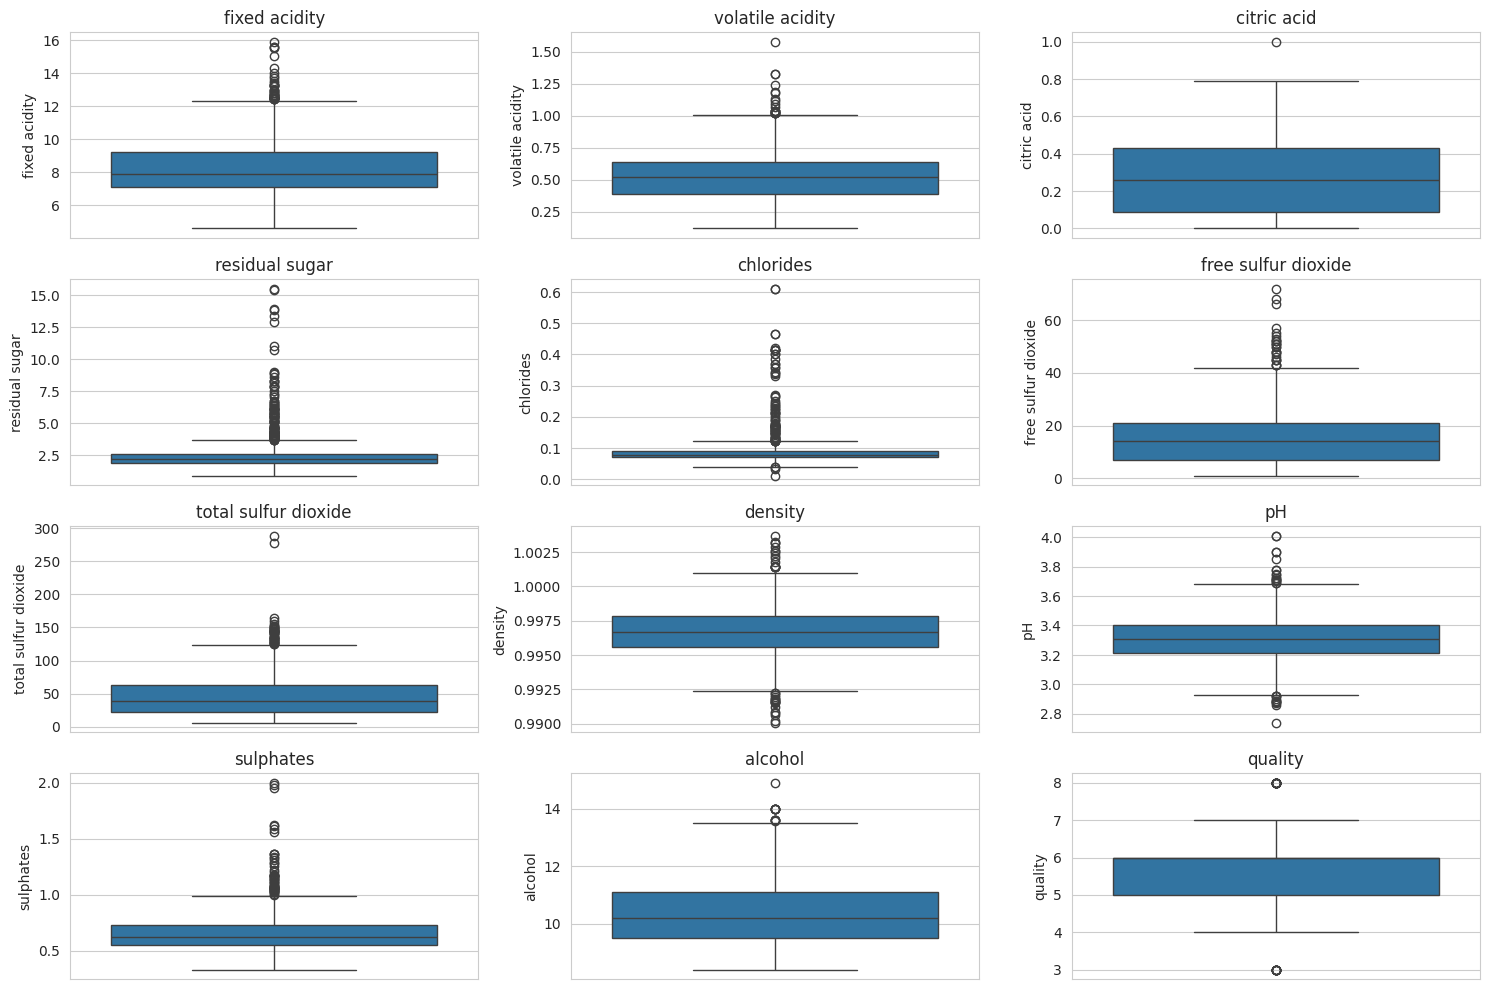

In [21]:
plt.figure(figsize=(15,10))

for i, column in enumerate(df.columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

Various outliers in the dataset.

# Wine Quality Distribution

/tmp/ipykernel_5419/989478056.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


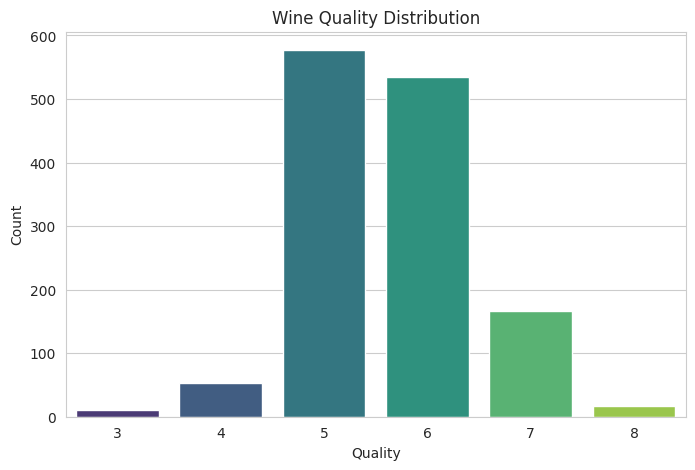

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='quality',
    data=df,
    palette='viridis'
)

plt.title("Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()


# The count plot indicates that:

- The wine quality dataset is imbalanced.
- Most wines are rated between 5 and 6.
- Extreme quality wines are rare.
- Special preprocessing techniques may be required for classification tasks to improve minority class prediction performance.

# Relationship with Quality


Correlation with Quality:
quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64


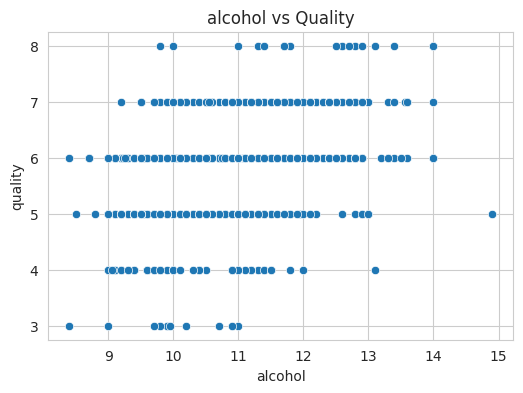

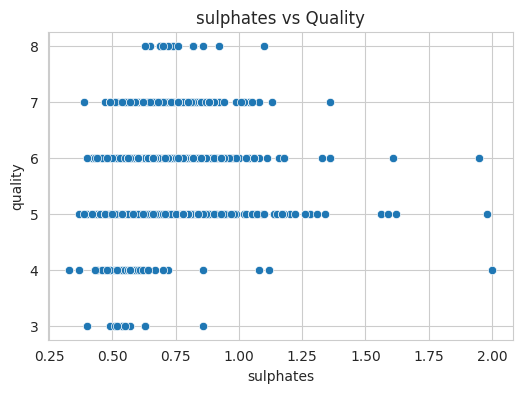

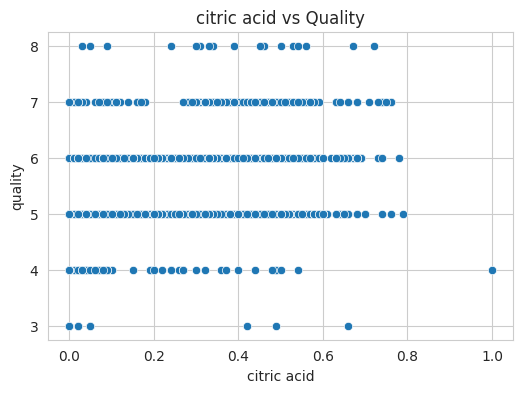

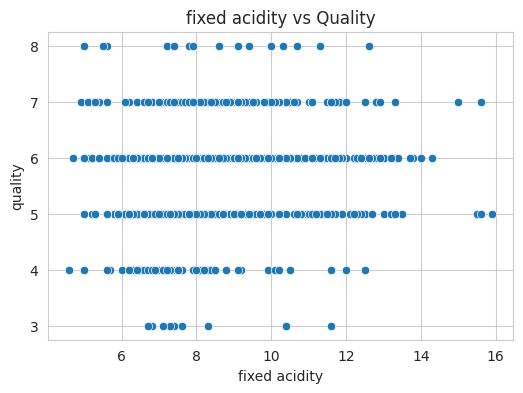

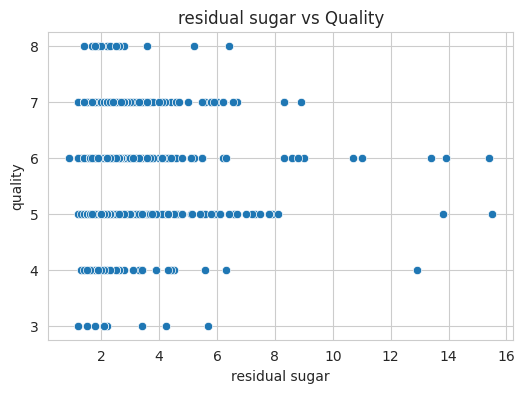

In [23]:
important_features = corr['quality'].sort_values(ascending=False)

print("\nCorrelation with Quality:")
print(important_features)

# Plot top correlated features
top_features = important_features.index[1:6]

for feature in top_features:
    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x=df[feature],
        y=df['quality']
    )

    plt.title(f"{feature} vs Quality")
    plt.show()


# From the correlation ranking and scatter plots:

- alcohol is the strongest positive predictor of wine quality.
- volatile acidity is the strongest negative predictor.
- Wine quality is influenced by multiple interacting chemical properties.
- Relationships are moderately linear, making both linear and tree-based models suitable for prediction tasks.

# Pairplot (Optional)

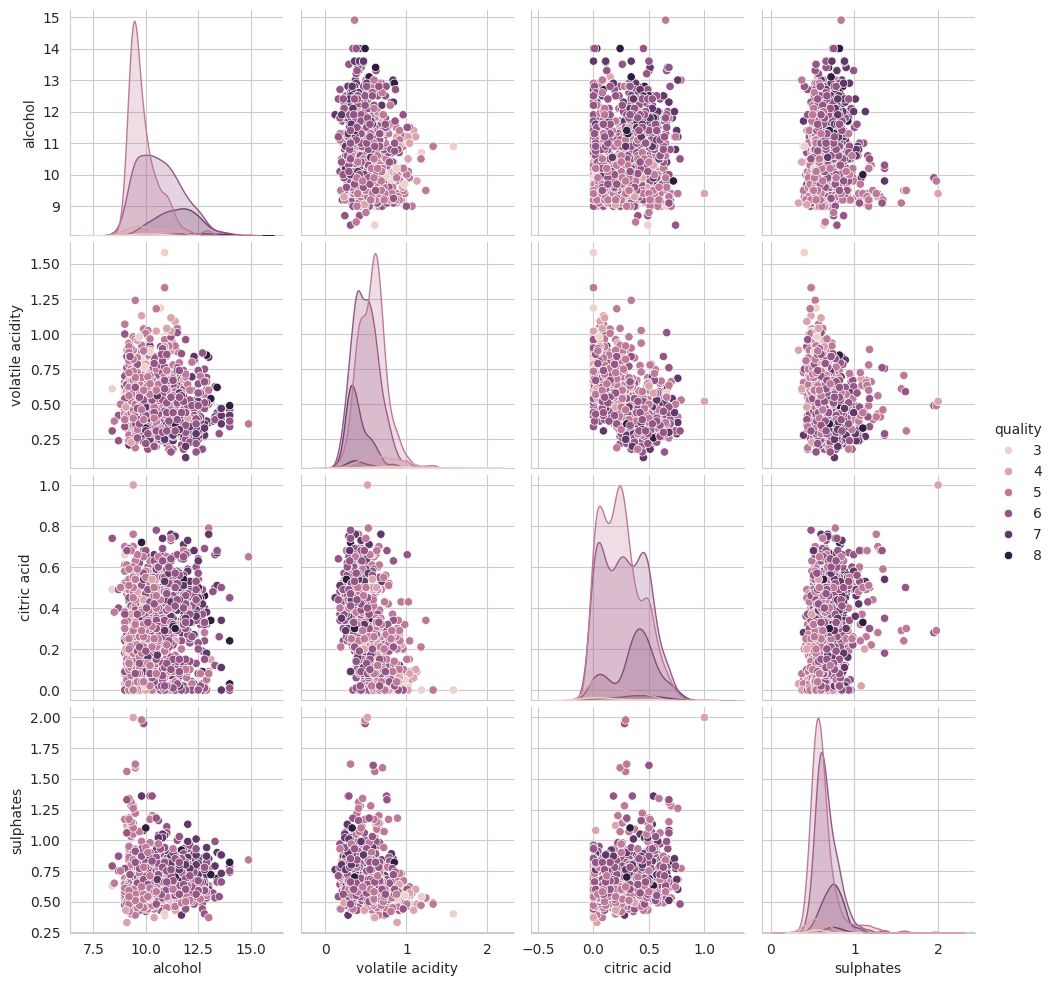

In [24]:
selected_cols = [
    'alcohol',
    'volatile acidity',
    'citric acid',
    'sulphates',
    'quality'
]

sns.pairplot(df[selected_cols], hue='quality')
plt.show()

# The pair plot reveals that:

- alcohol has the strongest positive relationship with quality.
- volatile acidity has the strongest negative relationship.
- Features interact with each other in complex ways.
- Wine quality classes overlap significantly, making prediction moderately challenging.

# Skewness Check

In [25]:
print("\nFeature Skewness:")
print(df.skew())


Feature Skewness:
fixed acidity           0.941041
volatile acidity        0.729279
citric acid             0.312726
residual sugar          4.548153
chlorides               5.502487
free sulfur dioxide     1.226579
total sulfur dioxide    1.540368
density                 0.044778
pH                      0.232032
sulphates               2.406505
alcohol                 0.859841
quality                 0.192407
dtype: float64


# The skewness analysis shows that:

- Several wine features are heavily right-skewed.
- Outliers exist in multiple variables.
- Feature transformation and scaling are recommended before training machine learning models.

#  Outlier Detection using IQR

In [26]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) |
            (df > (Q3 + 1.5 * IQR)))

print("\nOutliers per Feature:")
print(outliers.sum())


Outliers per Feature:
fixed acidity            41
volatile acidity         19
citric acid               1
residual sugar          126
chlorides                87
free sulfur dioxide      26
total sulfur dioxide     45
density                  35
pH                       28
sulphates                55
alcohol                  12
quality                  27
dtype: int64


# The IQR analysis shows that:

- Several features contain significant outliers.
- Outliers mainly occur in skewed chemical properties.
- Proper preprocessing is important before machine learning.
- Outlier handling can improve model stability and prediction performance.

 # Remove Outliers using IQR Method

In [28]:
# Calculate Q1 and Q3
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Remove outliers
df_no_outliers = df[
    ~((df < (Q1 - 1.5 * IQR)) |
      (df > (Q3 + 1.5 * IQR))).any(axis=1)
]

# Shape before and after
print("Original Shape:", df.shape)
print("Shape After Removing Outliers:", df_no_outliers.shape)

# Optional: Replace original dataframe
df = df_no_outliers

Original Shape: (1359, 12)
Shape After Removing Outliers: (1005, 12)


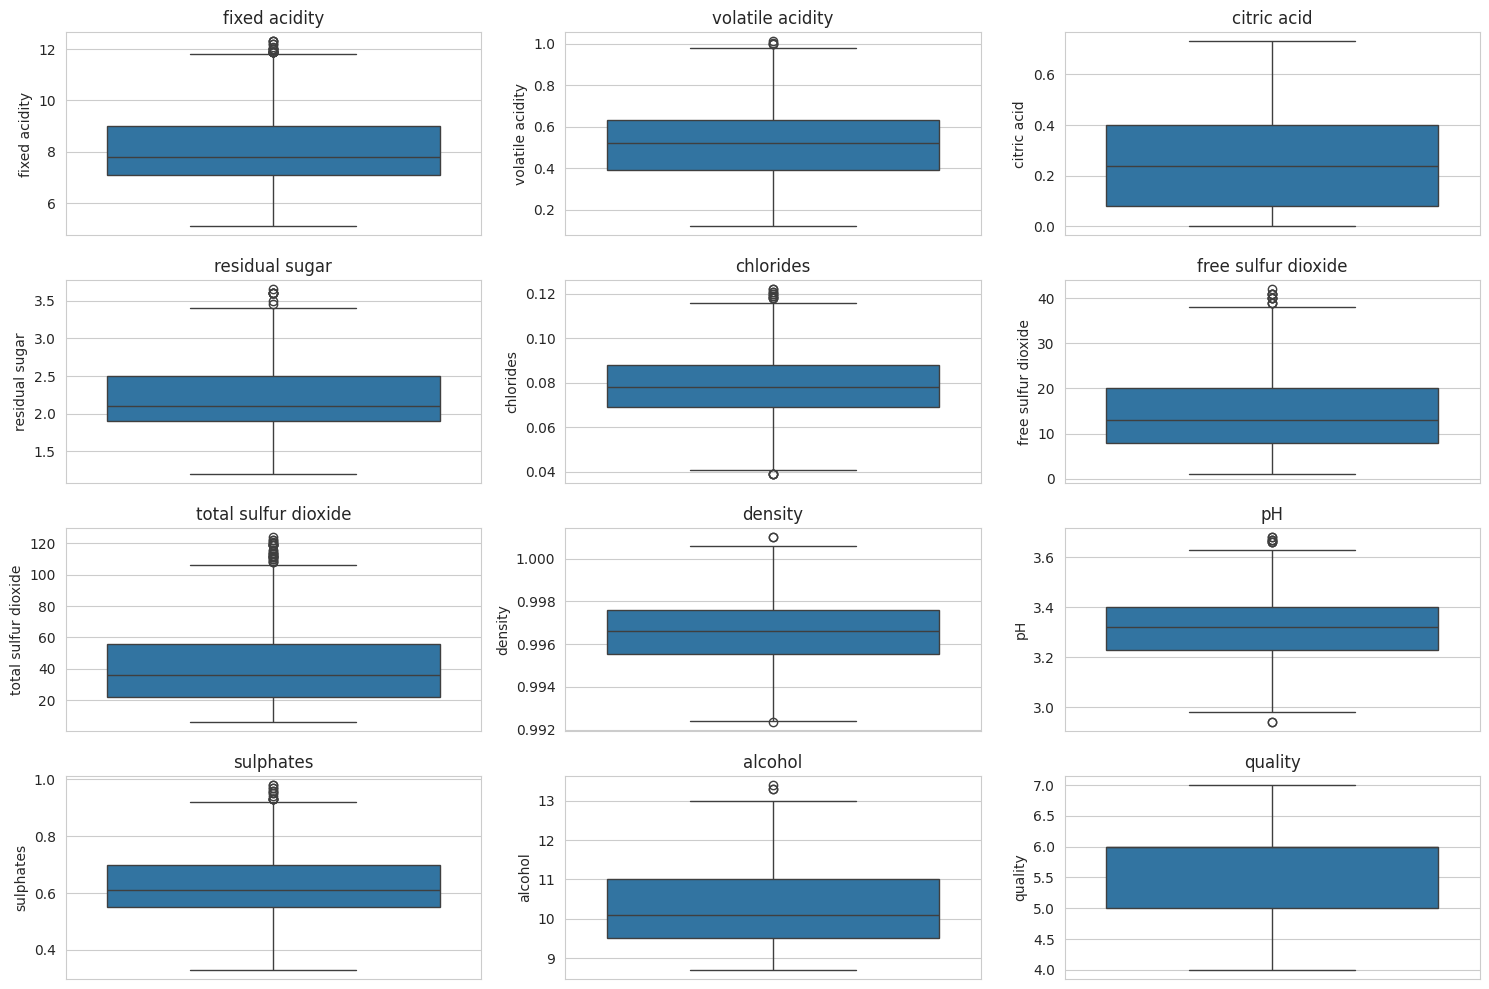

In [29]:
plt.figure(figsize=(15,10))

for i, column in enumerate(df.columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

Successfully remove outliers from the dataset.

#  Conclusions

In [30]:
print("\nEDA Completed Successfully!")


EDA Completed Successfully!
